In [263]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from matplotlib import lines
from sklearn.model_selection import GridSearchCV

In [264]:
df= pd.read_csv('world_population.csv')
df.head()

,Rank,CCA3,Country/Territory,Capital,Continent,2022 Population,2020 Population,2015 Population,2010 Population,2000 Population,1990 Population,1980 Population,1970 Population,Area (km²),Density (per km²),Growth Rate,World Population Percentage
0,36,AFG,Afghanistan,Kabul,Asia,41128771,38972230,33753499,28189672,19542982,10694796,12486631,10752971,652230,63.0587,1.0257,0.52
1,138,ALB,Albania,Tirana,Europe,2842321,2866849,2882481,2913399,3182021,3295066,2941651,2324731,28748,98.8702,0.9957,0.04
2,34,DZA,Algeria,Algiers,Africa,44903225,43451666,39543154,35856344,30774621,25518074,18739378,13795915,2381741,18.8531,1.0164,0.56
3,213,ASM,American Samoa,Pago Pago,Oceania,44273,46189,51368,54849,58230,47818,32886,27075,199,222.4774,0.9831,0.00
4,203,AND,Andorra,Andorra la Vella,Europe,79824,77700,71746,71519,66097,53569,35611,19860,468,170.5641,1.0100,0.00


In [265]:
df.info() #مفيش قيم فارغة
#فيه 4  object

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 234 entries, 0 to 233
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Rank                         234 non-null    int64  
 1   CCA3                         234 non-null    object 
 2   Country/Territory            234 non-null    object 
 3   Capital                      234 non-null    object 
 4   Continent                    234 non-null    object 
 5   2022 Population              234 non-null    int64  
 6   2020 Population              234 non-null    int64  
 7   2015 Population              234 non-null    int64  
 8   2010 Population              234 non-null    int64  
 9   2000 Population              234 non-null    int64  
 10  1990 Population              234 non-null    int64  
 11  1980 Population              234 non-null    int64  
 12  1970 Population              234 non-null    int64  
 13  Area (km²)          

In [266]:
#print(df.isnull().sum()) #مفيش قيم فارغة


In [267]:
cat_cols = [col for col in df.columns if df[col].dtype == 'object']
num_cols = [col for col in df.columns if df[col].dtype != 'object']


In [268]:
cat_cols

['CCA3', 'Country/Territory', 'Capital', 'Continent']

In [269]:
df.describe(include=object)

,CCA3,Country/Territory,Capital,Continent
count,234,234,234,234
unique,234,234,234,6
top,AFG,Afghanistan,Kabul,Africa
freq,1,1,1,57


In [270]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# نسخة جديدة من البيانات
df_clean = df.copy()

# 1- Label Encoding للأعمدة النصية
label_encoder = LabelEncoder()
df_clean['CCA3_enc'] = label_encoder.fit_transform(df_clean['CCA3'])
df_clean['Country_enc'] = label_encoder.fit_transform(df_clean['Country/Territory'])
df_clean['Capital_enc'] = label_encoder.fit_transform(df_clean['Capital'])

# 2- One-Hot Encoding لعمود القارة
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

continent_encoded = pd.DataFrame(
    ohe.fit_transform(df_clean[['Continent']]),
    columns=ohe.get_feature_names_out(['Continent']),
    index=df_clean.index
)

# 3- حذف الأعمدة النصية الأصلية
df_clean.drop(['CCA3', 'Country/Territory', 'Capital', 'Continent'], axis=1, inplace=True)

# 4- دمج الأعمدة الجديدة
df_final = pd.concat([df_clean, continent_encoded], axis=1)

# 5- إنشاء عمود Continent موحد من أعمدة الـ One-Hot Encoding
df_final['Continent'] = df_final[
    ['Continent_Africa', 'Continent_Asia', 'Continent_Europe',
     'Continent_North America', 'Continent_Oceania', 'Continent_South America']
].idxmax(axis=1)

df_final['Continent'] = df_final['Continent'].str.replace('Continent_', '', regex=False)

# معاينة أول 5 صفوف
print(df_final.head())

# عرض أسماء الأعمدة للتأكد
print(df_final.columns)

   Rank  2022 Population  2020 Population  2015 Population  2010 Population  \
0    36         41128771         38972230         33753499         28189672   
1   138          2842321          2866849          2882481          2913399   
2    34         44903225         43451666         39543154         35856344   
3   213            44273            46189            51368            54849   
4   203            79824            77700            71746            71519   

   2000 Population  1990 Population  1980 Population  1970 Population  \
0         19542982         10694796         12486631         10752971   
1          3182021          3295066          2941651          2324731   
2         30774621         25518074         18739378         13795915   
3            58230            47818            32886            27075   
4            66097            53569            35611            19860   

   Area (km²)  ...  CCA3_enc  Country_enc  Capital_enc  Continent_Africa  \
0      652

<Axes: xlabel='Area (km²)', ylabel='Density (per km²)'>

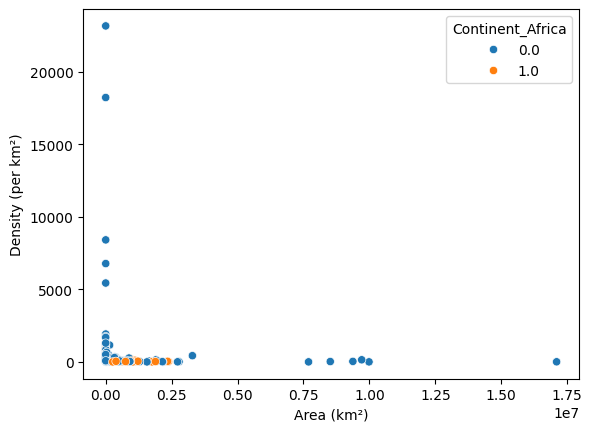

In [271]:
sns.scatterplot(data=df_final,
                x='Area (km²)', #مساحة الدولة.
                y='Density (per km²)', #الكثافة السكانية
                hue='Continent_Africa') #القارة (عشان يبان الفرق بين القارات).

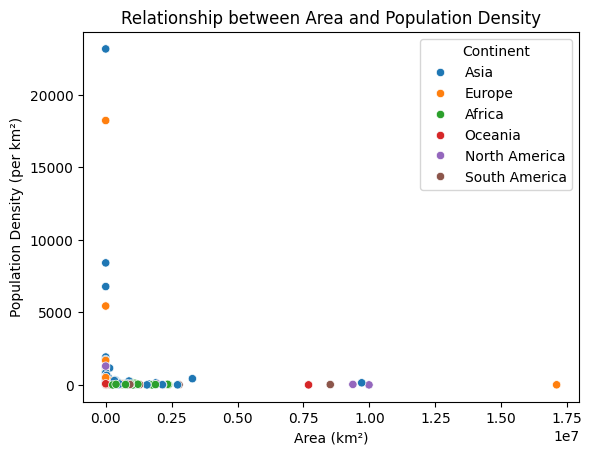

In [272]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    data=df_final,
    x='Area (km²)',
    y='Density (per km²)',
    hue='Continent'
)

plt.xlabel("Area (km²)")
plt.ylabel("Population Density (per km²)")
plt.title("Relationship between Area and Population Density")
plt.show()

In [273]:
from sklearn.cluster import KMeans

X = df_final[['Area (km²)', '2022 Population', 'Density (per km²)']]

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X)

df_final['Cluster'] = kmeans.labels_

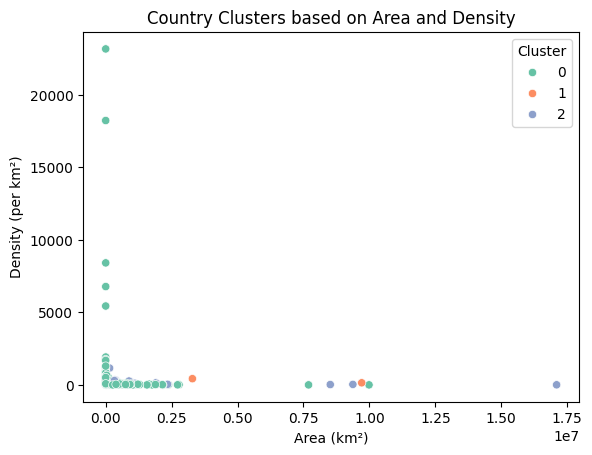

In [274]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    data=df_final,
    x='Area (km²)',
    y='Density (per km²)',
    hue='Cluster',
    palette='Set2'
)

plt.title("Country Clusters based on Area and Density")
plt.show()
# الـ KMeans سيقسم الدول إلى 5 مجموعات حسب:
# المساحة
# عدد السكان
# الكثافة السكانية
#يسمى Country Segmentation

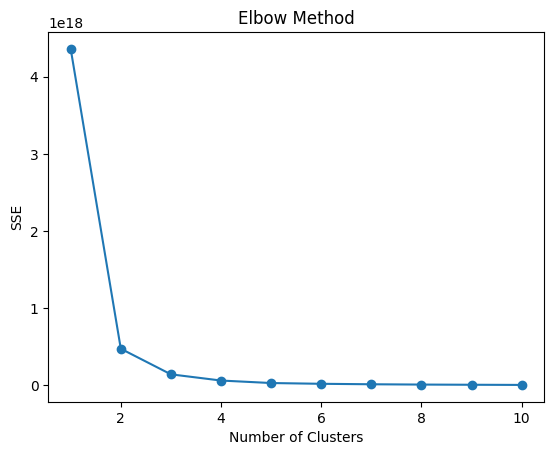

In [275]:
import matplotlib.pyplot as plt

sse = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    sse.append(kmeans.inertia_)

plt.plot(range(1,11), sse, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("SSE")
plt.title("Elbow Method")
plt.show()

The Elbow Method was used to determine the optimal number of clusters. The curve shows a clear elbow at K = 3, so three clusters were selected for the KMeans model.

In [276]:
# لذلك نقطة الانحناء تقريباً عند:
# 👉 K = 3
# يعني أفضل عدد مجموعات للدول هو 3 clusters.

In [277]:
sse

[4.359001056640604e+18,
 4.7567280537591443e+17,
 1.4403378431041483e+17,
 6.369502550077144e+16,
 3.138415426971067e+16,
 2.148322418917897e+16,
 1.536337657046697e+16,
 1.148014558127653e+16,
 8993622955560337.0,
 6903772022815880.0]

In [278]:
from sklearn.cluster import KMeans

X = df_final[['Area (km²)', '2022 Population', 'Density (per km²)']]

kmeans = KMeans(n_clusters=3, random_state=42) #تقسيم الدول الى 3
kmeans.fit(X)

df_final['Cluster'] = kmeans.labels_ #اضافة عمودCluster

In [279]:
from sklearn.model_selection import GridSearchCV
from sklearn.cluster import KMeans

# اختيار الأعمدة الرقمية
X = df_final[['Area (km²)', '2022 Population', 'Density (per km²)']]

kmeans = KMeans()

kmeans_params = {
    'n_clusters':[3,4,5,6,7,8],
    'init':['k-means++','random'],
    'max_iter':[300,400,500]
}

grid = GridSearchCV(kmeans, kmeans_params)

grid.fit(X)

print(grid.best_params_)
# ماذا يفعل هذا الكود؟
# هذا يسمى Hyperparameter Tuning.
# يقوم بتجربة:
# عدة قيم لـ عدد الكلستر
# عدة طرق للـ initialization
# عدة قيم لـ عدد التكرارات
# ثم يختار أفضل إعدادات للموديل

{'init': 'k-means++', 'max_iter': 300, 'n_clusters': 8}


In [280]:
from sklearn.cluster import KMeans

X = df_final[['Area (km²)', '2022 Population', 'Density (per km²)']]

kmeans_final = KMeans(
    n_clusters=8,
    init='k-means++',
    max_iter=400,
    random_state=42
)

df_final['Cluster'] = kmeans_final.fit_predict(X)

print(df_final.head())

   Rank  2022 Population  2020 Population  2015 Population  2010 Population  \
0    36         41128771         38972230         33753499         28189672   
1   138          2842321          2866849          2882481          2913399   
2    34         44903225         43451666         39543154         35856344   
3   213            44273            46189            51368            54849   
4   203            79824            77700            71746            71519   

   2000 Population  1990 Population  1980 Population  1970 Population  \
0         19542982         10694796         12486631         10752971   
1          3182021          3295066          2941651          2324731   
2         30774621         25518074         18739378         13795915   
3            58230            47818            32886            27075   
4            66097            53569            35611            19860   

   Area (km²)  ...  Country_enc  Capital_enc  Continent_Africa  \
0      652230  ...  

In [281]:
best_kmeans = grid.best_estimator_

df_final['Cluster'] = best_kmeans.fit_predict(X)

GridSearchCV was used to tune the KMeans hyperparameters in order to find the optimal number of clusters and initialization method.

In [282]:
print("Best Parameters:", grid.best_params_)

Best Parameters: {'init': 'k-means++', 'max_iter': 300, 'n_clusters': 8}


In [283]:
best_kmeans = grid.best_estimator_
df_final['Cluster'] = best_kmeans.fit_predict(X)

print(df_final[['Area (km²)', '2022 Population', 'Density (per km²)', 'Cluster']].head())

   Area (km²)  2022 Population  Density (per km²)  Cluster
0      652230         41128771            63.0587        5
1       28748          2842321            98.8702        2
2     2381741         44903225            18.8531        5
3         199            44273           222.4774        2
4         468            79824           170.5641        2


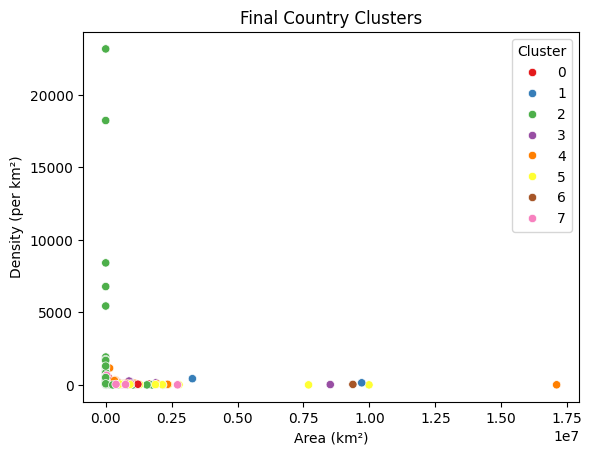

In [284]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    data=df_final,
    x='Area (km²)',
    y='Density (per km²)',
    hue='Cluster',
    palette='Set1'
)

plt.title("Final Country Clusters")
plt.show()

GridSearchCV was used to tune the KMeans hyperparameters. The best parameters found were n_clusters = 8, init = 'k-means++', and max_iter = 400, which were used to build the final clustering model

Final Clustering Visualization
The final visualization shows the clustering of countries based on area and population density using the optimized KMeans model. Each color represents a different cluster, grouping countries with similar geographic and demographic characteristics. These clusters help identify patterns and similarities among countries based on their size and population distribution